# Optimización de Pagos — FV Procesados

**Notebook reorganizado.** Antes cada modelo se construyó en un chat distinto, lo que dejó funciones duplicadas (varias versiones de `obtener_proyeccion`, `cargar_datos_flujo`, `construir_tabla_modelo5`...), nombres inconsistentes (`T` vs `HORIZONTE`) y variables usadas antes de definirse (`R`, `F`, `T` en el Modelo 3; faltaba `import cvxpy`).

Aquí queda **una sola versión** de cada función y un **único bloque de parámetros compartido** que alimenta a los tres modelos, para que sean directamente comparables.

Estructura:
1. Imports y configuración
2. Carga de datos
3. Proyección de flujo de efectivo
4. Parámetros comunes (T, L_min, D0, I, E, R, F)
5. Modelo 2 — Optimización global (QP)
6. Modelo 3 — Resiliencia
7. Modelo 5 — Opción A y CFO Prudente
8. Comparación final de los 3 modelos

## 1. Imports y configuración

In [1]:
# ============================================================
#  IMPORTS
# ============================================================
import numpy as np
import pandas as pd
from scipy.optimize import linprog
import cvxpy as cp
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

In [2]:
# ============================================================
#  CONFIGURACIÓN — MISMOS ARCHIVOS QUE USA EL DASHBOARD
# ============================================================
# IMPORTANTE: estas rutas deben apuntar a los mismos archivos que usa
# app.py (Streamlit). Si el dashboard corre en otra carpeta, ajustar aquí.
ARCHIVO_DATOS = "../Datos flujo de efectivo.xlsx"
ARCHIVO_PAGOS = "../Pagos pendientes.xlsx"

COLUMNAS_PAGOS = [
    "concepto", "categoría", "tipo", "importe", "semana",
    "inicio_semana", "fecha_registro", "estatus", "fecha_pago",
]

## 2. Carga de datos

**Corrección importante**: se detectó que el archivo de datos incluía una fila para la semana "03-08 julio 2026" con solo 4 transacciones (vs. ~20-30 en semanas completas) — es la semana en curso al momento de correr este notebook, no una semana histórica terminada. Incluirla distorsionaba la proyección (le daba el peso más alto en la media móvil ponderada, siendo además la semana con menos datos de todas). `cargar_datos_flujo` ahora excluye automáticamente cualquier semana cuya fecha de cierre (`inicio_semana + 6 días`) aún no haya pasado respecto a hoy, así este problema no se repite al correr el notebook en el futuro con datos más recientes.

In [3]:
def cargar_datos_flujo(ruta=ARCHIVO_DATOS):
    """Carga el histórico de movimientos (mismo formato que usa generar_flujo en el dashboard).

    Excluye automáticamente cualquier semana todavía en curso (inicio_semana + 6 días >= hoy),
    para que una semana parcialmente registrada no distorsione la proyección (ver nota en la
    celda de markdown de esta sección).
    """
    df = pd.read_excel(ruta)
    df["inicio_semana"] = pd.to_datetime(df["inicio_semana"], dayfirst=True)
    df["tipo"] = df["tipo"].astype(str).str.strip()
    df["categoría"] = df["categoría"].astype(str).str.strip()
    df["descripción"] = df["descripción"].astype(str).str.strip()
    df["importe"] = pd.to_numeric(df["importe"], errors="coerce").fillna(0)

    hoy = pd.Timestamp.today().normalize()
    fin_de_semana = df["inicio_semana"] + pd.Timedelta(days=6)
    semanas_incompletas = df.loc[fin_de_semana >= hoy, "inicio_semana"].unique()
    if len(semanas_incompletas) > 0:
        print(f"Aviso: se excluyeron {len(semanas_incompletas)} semana(s) incompleta(s) del "
              f"histórico (aún en curso): {[pd.Timestamp(s).date().isoformat() for s in semanas_incompletas]}")
        df = df.loc[fin_de_semana < hoy].copy()

    return df


def cargar_pagos_pendientes(ruta=ARCHIVO_PAGOS):
    """Carga pagos pendientes. Si el archivo no existe, retorna un DataFrame vacío
    con las columnas esperadas (igual que cargar_pagos() en el dashboard)."""
    try:
        dfp = pd.read_excel(ruta)
        for col in COLUMNAS_PAGOS:
            if col not in dfp.columns:
                dfp[col] = ""
        dfp = dfp[COLUMNAS_PAGOS]
    except FileNotFoundError:
        dfp = pd.DataFrame(columns=COLUMNAS_PAGOS)
    return dfp


def obtener_deudas_pendientes(dfp):
    """Agrupa la deuda pendiente por concepto/proveedor (D_i).

    Ordenado de MENOR a MAYOR a propósito: como el snowball paga las deudas más chicas
    primero, este orden hace que las columnas con actividad de pago real en las tablas
    queden a la IZQUIERDA (más fáciles de ver) en vez de perdidas hasta la derecha.
    """
    pend = dfp[dfp["estatus"] == "Pendiente"].copy()
    pend["importe"] = pd.to_numeric(pend["importe"], errors="coerce").fillna(0)
    resumen = pend.groupby("concepto")["importe"].sum()
    return resumen[resumen > 0].sort_values(ascending=True)


def calcular_saldo_actual(df):
    ingresos = df.loc[df["tipo"] == "Ingreso", "importe"].sum()
    egresos = df.loc[df["tipo"] == "Egreso", "importe"].sum()
    return float(ingresos - egresos)

In [4]:
# ============================================================
#  CARGA REAL DE DATOS
# ============================================================
df = cargar_datos_flujo()
dfp = cargar_pagos_pendientes()

deudas = obtener_deudas_pendientes(dfp)
saldo_actual = calcular_saldo_actual(df)

print(f"Movimientos históricos cargados: {len(df)}")
print(f"Pagos pendientes registrados: {len(dfp)}")
print(f"Deudas pendientes por concepto (D_i):")
display(deudas)
print(f"\nSaldo actual (C0): {saldo_actual:,.2f}")

Aviso: se excluyeron 1 semana(s) incompleta(s) del histórico (aún en curso): ['2026-07-03']
Movimientos históricos cargados: 536
Pagos pendientes registrados: 32
Deudas pendientes por concepto (D_i):


concepto
telefono                                           246.44
BOLSA                                              593.50
Contador Reymundo                                1,000.00
LAR seguro aveo                                  2,028.84
DIKEN                                            2,033.00
SIMA (Calibracion)                               2,500.00
CIPSA                                            3,886.00
PLATANO 1A/2A RECEPCION (12/11/25)/(14/11/25)    5,253.25
CIRAM                                            6,050.00
LORE                                             6,970.00
IMPUESTOS LAR                                    7,900.00
Bolsa Transparente (Chavinda)                    8,000.00
Edgar Joel Vega Martínez (Emplaye)               8,129.69
DEPACHO GARNICA                                  8,952.30
GASTOS                                          10,000.00
LORE (Transporte Personal)                      12,000.00
GLADYS (CERTIFICACION)                          15,000.00
JOSE 


Saldo actual (C0): -118,369.68


## 3. Proyección de flujo de efectivo

Se conserva **una sola versión**, la adaptativa (la simple de 6 semanas se eliminó por ser un caso particular ya cubierto por esta: con < 8 semanas de historial hace lo mismo, un promedio simple).

In [5]:
def obtener_proyeccion(df, horizonte):
    """
    Proyección adaptativa de ingresos y egresos semanales.

    Estrategia automática según la cantidad de semanas históricas:
        < 8 semanas       : promedio simple de todo el historial.
        8 a 51 semanas    : media móvil ponderada de las últimas 8 semanas.
        >= 52 semanas     : media móvil ponderada + factor estacional por
                            semana del año (ISO week).

    Siempre devuelve dos listas de longitud `horizonte`:
        I : ingresos proyectados por semana
        E : egresos proyectados por semana
    """
    resumen = df.pivot_table(
        index="inicio_semana", columns="tipo", values="importe",
        aggfunc="sum", fill_value=0,
    ).sort_index()

    for col in ["Ingreso", "Egreso"]:
        if col not in resumen.columns:
            resumen[col] = 0.0

    ingreso_hist = resumen["Ingreso"].values.astype(float)
    egreso_hist  = resumen["Egreso"].values.astype(float)
    n_semanas = len(ingreso_hist)

    pesos = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
    pesos = pesos / pesos.sum()

    def wma(serie):
        ultimas = serie[-8:]
        n = len(ultimas)
        pesos_ajustados = pesos[-n:]
        pesos_ajustados = pesos_ajustados / pesos_ajustados.sum()
        return np.dot(ultimas, pesos_ajustados)

    factores_ingreso = None
    factores_egreso = None
    if n_semanas >= 52:
        semanas_iso = resumen.index.isocalendar().week.values

        def calcular_factores(serie):
            df_temp = pd.DataFrame({"semana": semanas_iso, "valor": serie})
            promedio_semana = df_temp.groupby("semana")["valor"].mean()
            global_avg = serie.mean()
            if global_avg == 0:
                return {s: 1.0 for s in range(1, 54)}
            return (promedio_semana / global_avg).to_dict()

        factores_ingreso = calcular_factores(ingreso_hist)
        factores_egreso  = calcular_factores(egreso_hist)

    if n_semanas == 0:
        return [0.0] * horizonte, [0.0] * horizonte

    ultima_fecha = resumen.index[-1]
    fechas_futuras = pd.date_range(
        start=ultima_fecha + pd.Timedelta(weeks=1),
        periods=horizonte,
        freq="W"
    )
    semanas_futuras = fechas_futuras.isocalendar().week

    def proyectar(serie_hist, factores):
        if n_semanas < 8:
            base = serie_hist.mean()
            return np.full(horizonte, base)
        base = wma(serie_hist)
        if n_semanas < 52 or factores is None:
            return np.full(horizonte, base)
        proy = np.array([base * factores.get(s, 1.0) for s in semanas_futuras])
        return proy

    I = proyectar(ingreso_hist, factores_ingreso).tolist()
    E = proyectar(egreso_hist, factores_egreso).tolist()
    return I, E

## 4. Parámetros comunes

`L_MIN` y `L_SURVIVAL` ya **no se calculan automáticamente** a partir del saldo actual (`max(saldo_actual*0.1, 0)` daba 0 con saldo negativo, lo cual no reflejaba lo que pidió el cliente). Ahora son fijos, definidos por la operación real:

- `L_MIN = 200,000`: colchón cómodo — el nivel de caja con el que el cliente está tranquilo todo el año.
- `L_SURVIVAL = 10,000`: piso de emergencia — el mínimo tolerable en semanas de estrés antes de que la operación sea insostenible.

Ambos parámetros alimentan el mecanismo de **estrés dinámico** de los Modelos 1 y 3: en semanas tranquilas exigen el colchón cómodo, y en semanas de estrés ceden gradualmente hacia el piso de supervivencia, liberando presupuesto real para pagar deuda aun con caja negativa.

In [6]:
# ============================================================
#  PARÁMETROS COMUNES A LOS 3 MODELOS
# ============================================================
T = 8                     # horizonte de planeación en semanas
L_MIN = 200_000.0         # colchón cómodo (fijado por el cliente, ya no automático)
L_SURVIVAL = 10_000.0     # piso de emergencia (fijado por el cliente)

I, E = obtener_proyeccion(df, T)   # misma proyección adaptativa para los 3 modelos
C0 = saldo_actual
conceptos = deudas.index.tolist()
D0 = deudas.values.tolist()

# --- Solo para el Modelo 2: split de egresos en rígidos (R) vs flexibles (F) ---
FRACCION_FLEXIBLE = 0.3
E_arr = np.array(E, dtype=float)
F = FRACCION_FLEXIBLE * E_arr        # egresos que se pueden reprogramar ±s semanas
R = E_arr - F                        # egresos que deben pagarse en su semana

print(f"Horizonte (T): {T} semanas")
print(f"L_min (colchón cómodo): {L_MIN:,.2f}")
print(f"L_survival (piso de emergencia): {L_SURVIVAL:,.2f}")
print(f"Ingreso proyectado/semana: {I[0]:,.2f}")
print(f"Egreso proyectado/semana: {E[0]:,.2f}")
print(f"C0: {C0:,.2f}")
print(f"Conceptos con deuda ({len(conceptos)}): {conceptos}")
print(f"D0: {[round(d,2) for d in D0]}")

Horizonte (T): 8 semanas
L_min (colchón cómodo): 200,000.00
L_survival (piso de emergencia): 10,000.00
Ingreso proyectado/semana: 299,548.74
Egreso proyectado/semana: 314,809.05
C0: -118,369.68
Conceptos con deuda (31): ['telefono', 'BOLSA', 'Contador Reymundo', 'LAR seguro aveo', 'DIKEN', 'SIMA (Calibracion)', 'CIPSA', 'PLATANO 1A/2A RECEPCION (12/11/25)/(14/11/25)', 'CIRAM', 'LORE', 'IMPUESTOS LAR', 'Bolsa Transparente (Chavinda)', 'Edgar Joel Vega Martínez (Emplaye)', 'DEPACHO GARNICA', 'GASTOS', 'LORE (Transporte Personal)', 'GLADYS (CERTIFICACION)', 'JOSE HDEZ GARCIA (PAGO TARIMA)', 'TARIMA', 'EFECTIVO', 'NOMINA JACONA Y OCUMICHO SABADO', 'IMSS', 'Cristian Ramirez', 'CIELO (TARIMAS)', 'Ing Aguilar , embolsadora', 'AVV', 'RAISA', 'ROBERTO REYES', 'SINDULFO', 'IMSS CXM', 'CAJA RUTH GDL']
D0: [246.44, 593.5, 1000.0, 2028.84, 2033.0, 2500.0, 3886.0, 5253.25, 6050.0, 6970.0, 7900.0, 8000.0, 8129.69, 8952.3, 10000.0, 12000.0, 15000.0, 15370.0, 16240.0, 20000.0, 20000.0, 25000.0, 28500.0

## 5. Modelo 1 — Optimización global de caja (dos etapas)

**Diseño final**, tras encontrar que un solo QP compitiendo "proteger caja" vs. "pagar deuda" en un mismo objetivo era inestable (con el flujo actual, cualquier peso relativo producía o $0 de pago o un pago total de golpe en una sola semana, sin punto intermedio — ver el docstring de la función para el detalle matemático). La separación que sí funciona:

- **`PRESUPUESTO_DEUDA_GLOBAL`** (decisión de negocio, no matemática): en esta versión, Modelo 2 representa el extremo **agresivo** del espectro — paga la deuda casi por completo (100%), aceptando que la caja se degrade lo que tenga que degradarse. Es el contraste directo de Modelo 2 (que no paga nada). Modelo 3 queda en medio, con su propio presupuesto moderado.
- **Etapa A (QP)**: dado ese presupuesto ya fijo, decide *en qué semanas* conviene pagarlo para dañar lo menos posible la caja (protegiendo `L_min` y sobre todo `L_survival` vía penalización cuadrática), respetando un tope semanal realista (`<= 50% del ingreso proyectado de esa semana`, para que nunca sugiera un pago que la operación no tendría forma de cubrir).
- **Etapa B (snowball estricto)**: reparte el calendario de pagos ya decidido entre los conceptos de deuda, de la más chica a la más grande, saldando cada una por completo antes de tocar la siguiente — el mismo mecanismo de Modelo 3.

In [7]:
def modelo2_optimizacion_global(D0, I, E, C0, L_min, L_survival, T,
                                 presupuesto_deuda, pago_max_frac_ingreso=0.5,
                                 beta_survival=25.0, eps=1e-6):
    """
    Modelo 1 - Optimización global de caja (dos etapas).

    Diseño final (tras varias iteraciones): separar "cuánta deuda se paga en total"
    (decisión de negocio, `presupuesto_deuda`) de "en qué semanas conviene pagarla"
    (la parte que sí es un problema de optimización real).

    Etapa A (QP) - TIMING del presupuesto ya decidido:
        min  alpha * sum_t max(0, L_min - C_t)^2
           + alpha * beta_survival * sum_t max(0, L_survival - C_t)^2
        s.a. dinámica de caja y deuda,
             Pago[t] <= pago_max_frac_ingreso * I[t]   (tope semanal realista: nunca
                 destinar más de esa fracción del ingreso proyectado de la semana)
             sum(Pago) == presupuesto_deuda            (se gasta exactamente el
                 presupuesto de pago de deuda asignado para el horizonte)

    NOTA HISTÓRICA (por qué no hay una restricción dura de caja mínima, ni un peso
    "gamma" libre compitiendo entre deuda y liquidez):
    - Con el flujo proyectado actual (egresos > ingresos cada semana), la caja ya cae
      por debajo de cualquier piso positivo desde la semana 1 SIN pagar nada de deuda.
      Exigir `C[t] >= L_survival` como restricción dura vuelve el problema infeasible
      por construcción, sin importar qué tan bien se reparta el pago.
    - Poner el costo de la deuda en las mismas unidades que la penalización de
      liquidez (pesos vs. pesos-al-cuadrado-entre-L_min) produce un óptimo "bang-bang":
      con cualquier peso (`gamma`) el modelo paga $0 o paga TODO de golpe en una sola
      semana (hundiendo la caja de forma irreal), sin punto intermedio, porque las dos
      escalas son incomparables.
    - Fijar `presupuesto_deuda` como una decisión de negocio explícita (cuánta deuda
      quiero bajar este trimestre, dado que sé que cualquier pago perfora mi colchón)
      resuelve ambos problemas: siempre hay solución factible, y el QP se dedica
      exclusivamente a la pregunta que sí sabe resolver bien: en qué semanas ese
      presupuesto fijo hace menos daño a la caja.

    Etapa B (snowball estricto): reparte el presupuesto ya calendarizado entre los
        conceptos de deuda, de la más chica a la más grande, saldando cada una por
        completo antes de tocar la siguiente (idéntico criterio al Modelo 3).
    """
    D0 = np.asarray(D0, dtype=float)
    n = len(D0)
    D_total0 = D0.sum()
    I_arr = np.asarray(I, dtype=float)

    presupuesto_deuda = float(np.clip(presupuesto_deuda, 0.0, D_total0))
    tope_semanal = pago_max_frac_ingreso * I_arr
    if presupuesto_deuda > tope_semanal.sum():
        presupuesto_deuda = float(tope_semanal.sum())  # no pedir más de lo físicamente pagable

    alpha = 1.0 / (L_min ** 2) if L_min > 0 else 1.0 / (max(abs(C0), D_total0, 1.0) ** 2)

    # ---- Etapa A: timing del presupuesto fijo ----
    Pago = cp.Variable(T, nonneg=True)
    C = cp.Variable(T + 1)
    D_total = cp.Variable(T + 1)

    constraints = [C[0] == C0, D_total[0] == D_total0]
    for t in range(1, T + 1):
        idx = t - 1
        constraints.append(C[t] == C[t-1] + I[idx] - E[idx] - Pago[idx])
        constraints.append(D_total[t] == D_total[t-1] - Pago[idx])
        constraints.append(D_total[t] >= 0)
        constraints.append(Pago[idx] <= D_total[t-1])
        constraints.append(Pago[idx] <= tope_semanal[idx])
    constraints.append(cp.sum(Pago) == presupuesto_deuda)

    deficit_min = cp.pos(L_min - C[1:])
    deficit_survival = cp.pos(L_survival - C[1:])
    coste_liquidez = alpha * cp.sum_squares(deficit_min)
    coste_supervivencia = alpha * beta_survival * cp.sum_squares(deficit_survival)
    objetivo = cp.Minimize(coste_liquidez + coste_supervivencia)

    prob = cp.Problem(objetivo, constraints)
    prob.solve(solver=cp.OSQP, max_iter=50000, eps_abs=1e-6, eps_rel=1e-6)

    if prob.status not in ["optimal", "optimal_inaccurate", "user_limit"] or Pago.value is None:
        return np.zeros((n, T)), [0.0] * T, False

    pago_sem = np.clip(Pago.value, 0, None)
    C_opt = C.value

    # ---- Etapa B: snowball estricto sobre el calendario ya decidido ----
    D_restante = D0.copy()
    orden = np.argsort(D_restante)   # deuda más chica primero
    P = np.zeros((n, T))
    for t in range(T):
        restante_a_pagar = pago_sem[t]
        for i in orden:
            if restante_a_pagar <= 0:
                break
            abono = min(D_restante[i], restante_a_pagar)
            P[i, t] = abono
            D_restante[i] -= abono
            restante_a_pagar -= abono

    # ---- Ratios D/(C+L_min) recalculados con la deuda remanente real ----
    D_track = D0.copy()
    ratios = []
    for t in range(T):
        D_track = D_track - P[:, t]
        denom = C_opt[t+1] + L_min
        denom = denom if abs(denom) > eps else eps
        ratios.append(float(D_track.sum() / denom))

    return P, ratios, True

In [8]:
def construir_tabla_modelo(P, ratios, conceptos, I, E, C0, L_min):
    """Tabla de presentación compartida por los Modelos 2 y 5 (misma forma de salida)."""
    n, T = P.shape
    IE = np.array(I, dtype=float) - np.array(E, dtype=float)
    pagos_sem = P.sum(axis=0)
    C = C0 + np.cumsum(IE) - np.cumsum(pagos_sem)
    U = IE - pagos_sem

    filas = []
    for t in range(T):
        fila = {"Semana": t + 1}
        for i, concepto in enumerate(conceptos):
            fila[f"Pagar {concepto} ($)"] = round(float(P[i, t]), 2)
        fila["Utilidad/Retenida ($)"] = round(float(U[t]), 2)
        fila["Caja Proyectada ($)"] = round(float(C[t]), 2)
        fila["Ratio D/C"] = round(float(ratios[t]), 4)
        if C[t] <= L_min:
            estado = "Sin margen"
        elif C[t] <= L_min * 1.5:
            estado = "Ajustado"
        else:
            estado = "Operable"
        fila["Estado"] = estado
        filas.append(fila)

    return pd.DataFrame(filas)

In [9]:
PRESUPUESTO_DEUDA_GLOBAL = sum(D0)   # Modelo 1 = extremo agresivo: paga casi toda la deuda posible

P_2, ratios_2, exito_2 = modelo2_optimizacion_global(
    D0, I, E, C0, L_MIN, L_SURVIVAL, T,
    presupuesto_deuda=PRESUPUESTO_DEUDA_GLOBAL
)
tabla_2 = construir_tabla_modelo(P_2, ratios_2, conceptos, I, E, C0, L_MIN)
print(f"=== Modelo 1 - Optimización global, dos etapas (éxito: {exito_2}) ===")
print(f"Presupuesto de deuda asignado: {PRESUPUESTO_DEUDA_GLOBAL:,.2f} de {sum(D0):,.2f} totales")
display(tabla_2)

=== Modelo 1 - Optimización global, dos etapas (éxito: True) ===
Presupuesto de deuda asignado: 621,592.07 de 621,592.07 totales


/home/joseluisalmendarezgonzalez/miniconda3/envs/py_env/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,Semana,Pagar telefono ($),Pagar BOLSA ($),Pagar Contador Reymundo ($),Pagar LAR seguro aveo ($),Pagar DIKEN ($),Pagar SIMA (Calibracion) ($),Pagar CIPSA ($),Pagar PLATANO 1A/2A RECEPCION (12/11/25)/(14/11/25) ($),Pagar CIRAM ($),Pagar LORE ($),Pagar IMPUESTOS LAR ($),Pagar Bolsa Transparente (Chavinda) ($),Pagar Edgar Joel Vega Martínez (Emplaye) ($),Pagar DEPACHO GARNICA ($),Pagar GASTOS ($),Pagar LORE (Transporte Personal) ($),Pagar GLADYS (CERTIFICACION) ($),Pagar JOSE HDEZ GARCIA (PAGO TARIMA) ($),Pagar TARIMA ($),Pagar EFECTIVO ($),Pagar NOMINA JACONA Y OCUMICHO SABADO ($),Pagar IMSS ($),Pagar Cristian Ramirez ($),Pagar CIELO (TARIMAS) ($),"Pagar Ing Aguilar , embolsadora ($)",Pagar AVV ($),Pagar RAISA ($),Pagar ROBERTO REYES ($),Pagar SINDULFO ($),Pagar IMSS CXM ($),Pagar CAJA RUTH GDL ($),Utilidad/Retenida ($),Caja Proyectada ($),Ratio D/C,Estado
0,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-15,260.31","-133,629.99",9.37,Sin margen
1,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-15,260.31","-148,890.30",12.16,Sin margen
2,3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-15,260.31","-164,150.60",17.34,Sin margen
3,4,246.44,593.50,"1,000.00","2,028.84","2,033.00","2,500.00","3,886.00","5,253.25","4,953.67",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-37,755.00","-201,905.61",-314.39,Sin margen
4,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"1,096.33","6,970.00","7,900.00","8,000.00","8,129.69","8,952.30","10,000.00","12,000.00","15,000.00","15,370.00","16,240.00","20,000.00","20,000.00",116.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-165,034.67","-366,940.28",-2.69,Sin margen
5,6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"24,883.97","28,500.00","32,480.00","35,178.00","28,732.39",0.00,0.00,0.00,0.00,0.00,"-165,034.66","-531,974.94",-0.90,Sin margen
6,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"10,267.61","40,000.00","49,247.80","49,247.80","1,011.13",0.00,"-165,034.65","-697,009.59",-0.30,Sin margen
7,8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"72,035.47","77,738.85","-165,034.63","-862,044.22",-0.00,Sin margen


## 6. Modelo 2 — Máxima resiliencia financiera

Maximiza el piso de caja reprogramando los egresos flexibles (`F`) dentro de una ventana `±s` semanas, respetando los egresos rígidos (`R`).

**Rol en el espectro**: este es el extremo de **máxima protección de caja** — por diseño, nunca toca `D0` ni paga un peso de deuda (solo reprograma egresos). Es el contraste directo de Modelo 1 (que paga casi toda la deuda). La propia matemática del problema confirma que esto es lo correcto: dado el déficit estructural, cualquier peso destinado a deuda es un peso menos de colchón (ver Modelo 1/3), así que "no pagar nada" es, en efecto, la estrategia que más protege la caja — Modelo 2 simplemente lo hace explícito al no participar del pago de deuda en absoluto.

**Mismo ajuste que en Modelo 1 y 3**: `L_min` dejó de ser una restricción dura (`m >= L_min`). Con el flujo proyectado real, el piso máximo alcanzable por reprogramación es muy inferior a cualquier `L_min`/`L_survival` positivo — exigirlo como obligatorio volvía el problema infeasible sin importar cómo se reacomodaran los pagos. Ahora `L_min`/`L_survival` son solo referencia para *etiquetar* qué tan lejos queda el piso alcanzado, no una condición que deba cumplirse.

**Además se agrega la métrica de valor real de este modelo: la "resiliencia ganada"** — cuánto mejora el piso de caja gracias a la reprogramación, comparado contra el piso que resultaría sin reprogramar nada. Esto importa porque, matemáticamente, **si la semana más crítica es la última del horizonte, la ganancia siempre será $0**: para cuando termina el horizonte, ya se gastó el 100% de los egresos sin importar el orden en que se pagaron, así que la caja acumulada al final es invariante ante cualquier reprogramación. La reprogramación solo puede ayudar cuando el punto más crítico ocurre *antes* del final del horizonte. Con el pronóstico plano actual (ingreso y egreso proyectados iguales cada semana), la caja cae de forma monótona y la semana crítica siempre es la última — por eso, con tus datos reales, la ganancia da $0. Esto es un resultado correcto y esperado, no un error del modelo.

In [10]:
def modelo3_resiliencia(
    I, E, C0, T,
    R, F, s,
    E_max=None,
    L_min=None,       # ya NO es restricción dura; solo se usa como referencia informativa
    D0=None           # ignorado, solo por uniformidad con los otros modelos
):
    """
    Modelo 2 - Resiliencia pura del flujo de caja.
    Maximiza el piso de caja reprogramando los egresos flexibles dentro de una
    ventana temporal +-s.

    NOTA: en la version anterior, L_min se imponia como restriccion dura (m >= L_min),
    lo que volvia el problema infeasible en cuanto el flujo proyectado hacia imposible
    alcanzar ese piso (exactamente el mismo problema que tuvieron Modelo 1 y 3). Ahora
    L_min/L_survival solo se usan para ETIQUETAR que tan lejos queda el piso alcanzado,
    nunca como condicion obligatoria -> el modelo siempre encuentra solucion.
    """
    I = np.asarray(I, dtype=float)
    E = np.asarray(E, dtype=float)
    R = np.asarray(R, dtype=float)
    F = np.asarray(F, dtype=float)
    if not (len(I) == len(E) == len(R) == len(F) == T):
        raise ValueError("I, E, R, F deben tener longitud T")
    if np.any(F < 0) or np.any(R < 0):
        raise ValueError("R y F deben ser no negativos")

    # --- Piso base: el que resulta SIN reprogramar nada (para medir la ganancia real) ---
    C_base = np.zeros(T+1)
    C_base[0] = C0
    for t in range(1, T+1):
        C_base[t] = C_base[t-1] + I[t-1] - E[t-1]
    m_base = float(np.min(C_base[1:]))

    if np.all(F == 0):
        m_opt = m_base
        return dict(
            m_opt=m_opt, m_base=m_base, ganancia=0.0,
            C_opt=C_base.tolist(), E_opt=E.tolist(), x_opt={}, exito=True,
            t_crit=int(np.argmin(C_base[1:])) + 1,
            K_star=(np.max(E) / np.sum(E)) if np.sum(E) > 0 else np.nan
        )

    pairs = []
    idx_map = {}
    n_x = 0
    for tau in range(T):
        t_start = max(0, tau - s)
        t_end = min(T, tau + s + 1)
        for t in range(t_start, t_end):
            pairs.append((tau, t))
            idx_map[(tau, t)] = n_x
            n_x += 1

    n_vars = n_x + 1
    idx_m = n_x

    c = np.zeros(n_vars)
    c[idx_m] = -1.0

    A_eq = []
    b_eq = []
    for tau in range(T):
        row = np.zeros(n_vars)
        t_start = max(0, tau - s)
        t_end = min(T, tau + s + 1)
        for t in range(t_start, t_end):
            row[idx_map[(tau, t)]] = 1.0
        A_eq.append(row)
        b_eq.append(F[tau])
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    A_ub = []
    b_ub = []

    cum_I = np.cumsum(I)
    cum_R = np.cumsum(R)
    # Restriccion: C[t] >= m  <=>  m + sum(x reprogramado hasta t) <= C0 + cum_I[t-1] - cum_R[t-1]
    for t_idx in range(1, T+1):
        row = np.zeros(n_vars)
        for k in range(t_idx):
            tau_start = max(0, k - s)
            tau_end = min(T, k + s + 1)
            for tau in range(tau_start, tau_end):
                if (tau, k) in idx_map:
                    row[idx_map[(tau, k)]] += 1.0
        row[idx_m] = 1.0
        rhs = C0 + cum_I[t_idx-1] - cum_R[t_idx-1]
        A_ub.append(row)
        b_ub.append(rhs)

    if E_max is not None:
        E_max = np.asarray(E_max, dtype=float)
        if len(E_max) != T:
            raise ValueError("E_max debe tener longitud T")
        for t in range(T):
            if np.isfinite(E_max[t]):
                row = np.zeros(n_vars)
                tau_start = max(0, t - s)
                tau_end = min(T, t + s + 1)
                for tau in range(tau_start, tau_end):
                    row[idx_map[(tau, t)]] = 1.0
                rhs = E_max[t] - R[t]
                A_ub.append(row)
                b_ub.append(rhs)

    # L_min ya NO se agrega como restriccion dura (ver nota en el docstring)

    A_ub = np.array(A_ub) if A_ub else None
    b_ub = np.array(b_ub) if b_ub else None

    bounds = [(0, None)] * n_x + [(None, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method='highs')

    if not res.success:
        return dict(m_opt=np.nan, m_base=m_base, ganancia=np.nan, C_opt=[], E_opt=[],
                    x_opt={}, exito=False, t_crit=None, K_star=np.nan)

    x_sol = res.x[:n_x]
    m_opt = res.x[idx_m]

    x_opt = {pair: x_sol[idx_map[pair]] for pair in pairs}

    E_opt = np.copy(R)
    for (tau, t), val in x_opt.items():
        E_opt[t] += val

    C_opt = np.zeros(T+1)
    C_opt[0] = C0
    for t in range(1, T+1):
        C_opt[t] = C_opt[t-1] + I[t-1] - E_opt[t-1]

    t_crit = int(np.argmin(C_opt[1:])) + 1
    sum_E_opt = np.sum(E_opt)
    K_star = np.max(E_opt) / sum_E_opt if sum_E_opt > 0 else np.nan

    return dict(m_opt=m_opt, m_base=m_base, ganancia=float(m_opt - m_base),
                C_opt=C_opt.tolist(), E_opt=E_opt.tolist(), x_opt=x_opt,
                exito=True, t_crit=t_crit, K_star=K_star)


def construir_tabla_modelo3(res, L_min=None, L_survival=None):
    if not res['exito']:
        return pd.DataFrame({'Error': ['Optimización fallida']})
    df_tabla = pd.DataFrame({
        'Semana': list(range(len(res['C_opt']))),
        'Caja': res['C_opt'],
        'Egreso_reprogramado': [res['E_opt'][t-1] if t > 0 else np.nan for t in range(len(res['C_opt']))]
    })
    filas_metricas = [
        ('---', ''),
        ('Piso SIN reprogramar (m_base)', res['m_base']),
        ('Piso CON reprogramación (m*)', res['m_opt']),
        ('Resiliencia ganada (m* - m_base)', res['ganancia']),
        ('Semana crítica', res['t_crit']),
        ('Índice K*', res['K_star']),
    ]
    if L_min is not None:
        filas_metricas.append(('L_min (colchón cómodo, referencia)', L_min))
    if L_survival is not None:
        filas_metricas.append(('L_survival (piso de emergencia, referencia)', L_survival))
    metricas = pd.DataFrame({
        'Semana': [f[0] for f in filas_metricas],
        'Caja': [f[1] for f in filas_metricas],
        'Egreso_reprogramado': [''] * len(filas_metricas)
    })
    return pd.concat([df_tabla, metricas], ignore_index=True)

In [11]:
# Ventana de desplazamiento permitida para reprogramar egresos flexibles
s = 2

res_m3 = modelo3_resiliencia(
    I, E, C0, T,
    R, F, s,
    E_max=None,       # o un array con límites por semana
    L_min=L_MIN,      # ya solo es referencia informativa, no restricción dura
    D0=D0             # se ignora, solo por compatibilidad
)

tabla_m3 = construir_tabla_modelo3(res_m3, L_min=L_MIN, L_survival=L_SURVIVAL)
print(f"=== Modelo 2 - Resiliencia (éxito: {res_m3['exito']}) ===")
print(f"Piso sin reprogramar: {res_m3['m_base']:,.2f}  |  Piso con reprogramación: {res_m3['m_opt']:,.2f}  |  Ganancia: {res_m3['ganancia']:,.2f}")
display(tabla_m3)

=== Modelo 2 - Resiliencia (éxito: True) ===
Piso sin reprogramar: -240,452.15  |  Piso con reprogramación: -240,452.15  |  Ganancia: -0.00


,Semana,Caja,Egreso_reprogramado
0,0,"-118,369.68",NaN
1,1,"-39,187.27","220,366.34"
2,2,"-148,890.30","409,251.77"
3,3,"-164,150.60","314,809.05"
4,4,"-179,410.91","314,809.05"
5,5,"-194,671.22","314,809.05"
6,6,"-209,931.53","314,809.05"
7,7,"-225,191.84","314,809.05"
8,8,"-240,452.15","314,809.05"
9,---,,


## 7. Modelo 3 — Ratio de Pago

Se eliminó la variante **Opción A** (agresividad fija) por decisión del cliente.

**Rol en el espectro**: este es el punto **medio** entre Modelo 1 (agresivo, paga casi toda la deuda) y Modelo 2 (no paga nada). Mantiene su propio presupuesto moderado (`PRESUPUESTO_DEUDA_RATIO`, 25% de la deuda por default), independiente del de Modelo 1.

**Rediseño del mecanismo de estrés**: la versión original decidía *si* pagar según si la caja superaba un piso absoluto (`excedente = max(0, caja - piso)`). Con el flujo real (egresos > ingresos), la caja nunca supera ningún piso positivo, así que ese excedente siempre daba 0 y el modelo nunca pagaba — lo opuesto de "recomendar pagar aun con caja negativa".

Ahora el estrés dinámico decide **el ritmo** al que se gasta su presupuesto: acelera en semanas de bajo estrés, desacelera —pero nunca a cero— en semanas críticas. Se agregó también un **barrido final** que garantiza agotar el presupuesto asignado para el final del horizonte (antes podía quedar dinero sin ejercer si el ritmo era demasiado conservador). Snowball estricto (deuda más chica primero) se mantiene igual que antes.

In [12]:
def modelo5_cfo_prudente(D0, I, E, C0, T, presupuesto_deuda, L_min=200_000.0, L_survival=10_000.0,
                         pago_max_frac_ingreso=0.5, D_crit=5.0, piso_agres=0.2, epsilon=1e-6):
    """
    Modelo 3 - Ratio de Pago (heurística snowball con estrés dinámico).

    NOTA (por qué cambió respecto a la versión anterior): el mecanismo original definía
    `excedente = max(0, caja_actual - piso_dinamico)` y solo pagaba si ese excedente era
    positivo. Con el flujo proyectado real (egresos > ingresos cada semana), la caja SIEMPRE
    está muy por debajo de cualquier piso positivo -> excedente = 0 siempre -> nunca paga nada,
    justo lo opuesto de "recomendar pagar aun cuando la caja sea negativa".

    Ahora el estrés ya no decide SI se paga, sino EL RITMO al que se gasta un presupuesto de
    deuda ya aprobado (`presupuesto_deuda`): en semanas de bajo estrés acelera el ritmo, en
    semanas críticas lo desacelera (nunca a cero, gracias al piso `piso_agres`), siempre
    respetando un tope semanal realista.

    CORRECCIÓN ADICIONAL: el ritmo basado en estrés no garantizaba agotar el presupuesto para
    el final del horizonte (podía quedar dinero "sin gastar" por ser demasiado conservador
    semana a semana). Se agrega un "barrido final": en la última semana, si queda presupuesto
    sin ejercer, se paga ese remanente por completo (respetando el tope semanal realista y la
    deuda restante), para que el presupuesto asignado sí se agote como se espera.
    """
    n = len(D0)
    D_restante = np.array(D0, dtype=float)
    C = C0
    P = np.zeros((n, T))
    ratios = []
    presupuesto_restante = float(presupuesto_deuda)

    for t in range(T):
        C_disp = C + (I[t] - E[t])
        semanas_restantes = T - t
        ritmo_base = presupuesto_restante / semanas_restantes  # reparto parejo de lo que queda

        # --- estrés: qué tan crítica está la caja / la carga de deuda ---
        liq_ratio = (C_disp + L_min) / (L_min + epsilon)
        stress_liq = float(np.clip(1.0 - liq_ratio, 0.0, 1.0))
        denom = max(abs(C_disp) + L_min, epsilon)
        stress_debt = min(D_restante.sum() / denom / D_crit, 1.0)
        s_stress = max(stress_liq, stress_debt)

        agresividad = max(1.0 - s_stress, piso_agres)   # nunca baja de piso_agres
        pago_objetivo = agresividad * ritmo_base * 2.0  # *2: permite acelerar en semanas holgadas

        tope_semana = pago_max_frac_ingreso * I[t]

        es_ultima_semana = (t == T - 1)
        if es_ultima_semana:
            # Barrido final: agota lo que quede del presupuesto, sin importar el ritmo de estrés
            pago_objetivo = presupuesto_restante

        pago_total = max(0.0, min(pago_objetivo, tope_semana, presupuesto_restante, D_restante.sum()))

        if pago_total > 0:
            orden = np.argsort(D_restante)   # snowball: deuda más chica primero
            restante = pago_total
            for i in orden:
                if restante <= 0:
                    break
                abono = min(D_restante[i], restante)
                P[i, t] = abono
                D_restante[i] -= abono
                restante -= abono

        pagado_esta_semana = P[:, t].sum()
        presupuesto_restante -= pagado_esta_semana
        C = C_disp - pagado_esta_semana
        ratio_t = D_restante.sum() / (C + L_min + epsilon)
        ratios.append(ratio_t)

    return P, ratios, True

In [13]:
PRESUPUESTO_DEUDA_RATIO = 0.25 * sum(D0)   # Modelo 3 = punto medio: 25% de la deuda, ritmo moderado

P_cfo, ratios_cfo, exito_cfo = modelo5_cfo_prudente(
    D0, I, E, C0, T,
    presupuesto_deuda=PRESUPUESTO_DEUDA_RATIO,
    L_min=L_MIN, L_survival=L_SURVIVAL
)
tabla_cfo = construir_tabla_modelo(P_cfo, ratios_cfo, conceptos, I, E, C0, L_MIN)
print("=== Modelo 3 - Ratio de Pago (heurística snowball adaptativa) ===")
print(f"Presupuesto de deuda asignado: {PRESUPUESTO_DEUDA_RATIO:,.2f} de {sum(D0):,.2f} totales")
display(tabla_cfo)

=== Modelo 3 - Ratio de Pago (heurística snowball adaptativa) ===
Presupuesto de deuda asignado: 155,398.02 de 621,592.07 totales


,Semana,Pagar telefono ($),Pagar BOLSA ($),Pagar Contador Reymundo ($),Pagar LAR seguro aveo ($),Pagar DIKEN ($),Pagar SIMA (Calibracion) ($),Pagar CIPSA ($),Pagar PLATANO 1A/2A RECEPCION (12/11/25)/(14/11/25) ($),Pagar CIRAM ($),Pagar LORE ($),Pagar IMPUESTOS LAR ($),Pagar Bolsa Transparente (Chavinda) ($),Pagar Edgar Joel Vega Martínez (Emplaye) ($),Pagar DEPACHO GARNICA ($),Pagar GASTOS ($),Pagar LORE (Transporte Personal) ($),Pagar GLADYS (CERTIFICACION) ($),Pagar JOSE HDEZ GARCIA (PAGO TARIMA) ($),Pagar TARIMA ($),Pagar EFECTIVO ($),Pagar NOMINA JACONA Y OCUMICHO SABADO ($),Pagar IMSS ($),Pagar Cristian Ramirez ($),Pagar CIELO (TARIMAS) ($),"Pagar Ing Aguilar , embolsadora ($)",Pagar AVV ($),Pagar RAISA ($),Pagar ROBERTO REYES ($),Pagar SINDULFO ($),Pagar IMSS CXM ($),Pagar CAJA RUTH GDL ($),Utilidad/Retenida ($),Caja Proyectada ($),Ratio D/C,Estado
0,1,246.44,593.50,"1,000.00","2,028.84","2,033.00","2,500.00","3,886.00",604.43,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-28,152.52","-146,522.20",11.38,Sin margen
1,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"4,648.82","3,494.37",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-23,403.50","-169,925.69",19.97,Sin margen
2,3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,555.63","6,401.88",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-24,217.82","-194,143.51",101.02,Sin margen
3,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,568.12,"7,900.00","1,564.29",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-25,292.72","-219,436.23",-29.92,Sin margen
4,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"6,435.71","5,101.56",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-26,797.58","-246,233.81",-12.33,Sin margen
5,6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"3,028.13","8,952.30","1,864.29",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-29,105.03","-275,338.84",-7.38,Sin margen
6,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"8,135.71","9,862.43",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-33,258.45","-308,597.29",-4.96,Sin margen
7,8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,137.57","15,000.00","15,370.00","16,240.00","20,000.00","3,245.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-87,252.87","-395,850.17",-2.38,Sin margen


## 8. Comparación final de los modelos

Los tres modelos representan un **espectro completo del trade-off caja vs. deuda**:

- **Modelo 1 (Global)**: extremo agresivo — paga casi toda la deuda, la caja se degrada más.
- **Modelo 3 (Ratio de Pago)**: punto medio — paga una porción moderada (25%), a un ritmo adaptativo.
- **Modelo 2 (Resiliencia)**: extremo conservador — no paga nada de deuda, solo reprograma egresos; es el que mejor protege la caja, al costo de no reducir la deuda en absoluto.

La gráfica usa **doble eje Y** — caja proyectada (izquierda) y deuda restante (derecha) — para que se vea directamente cómo, entre los tres modelos, mientras más se protege la caja, más deuda queda pendiente, y viceversa.

=== Comparación de caja y deuda restante por modelo ===


,Semana,Caja Modelo 1 (Global),Caja Modelo 2 (Resiliencia),Caja Modelo 3 (Ratio de Pago),Deuda restante Modelo 1 (Global),Deuda restante Modelo 2 (Resiliencia),Deuda restante Modelo 3 (Ratio de Pago)
0,1,"-133,629.99","-39,187.27","-146,522.20","621,592.07","621,592.07","608,699.86"
1,2,"-148,890.30","-148,890.30","-169,925.69","621,592.07","621,592.07","600,556.67"
2,3,"-164,150.60","-164,150.60","-194,143.51","621,592.07","621,592.07","591,599.16"
3,4,"-201,905.61","-179,410.91","-219,436.23","599,097.37","621,592.07","581,566.75"
4,5,"-366,940.28","-194,671.22","-246,233.81","449,323.02","621,592.07","570,029.48"
5,6,"-531,974.94","-209,931.53","-275,338.84","299,548.66","621,592.07","556,184.76"
6,7,"-697,009.59","-225,191.84","-308,597.29","149,774.32","621,592.07","538,186.62"
7,8,"-862,044.22","-240,452.15","-395,850.17",0.00,"621,592.07","466,194.05"



=== Resumen comparativo ===


,Modelo,Piso de caja mínimo,Deuda final restante,% de deuda pagada
0,Modelo 1 (Global),"-862,044.22",0.00,100.00
1,Modelo 2 (Resiliencia),"-240,452.15","621,592.07",0.00
2,Modelo 3 (Ratio de Pago),"-395,850.17","466,194.05",25.00


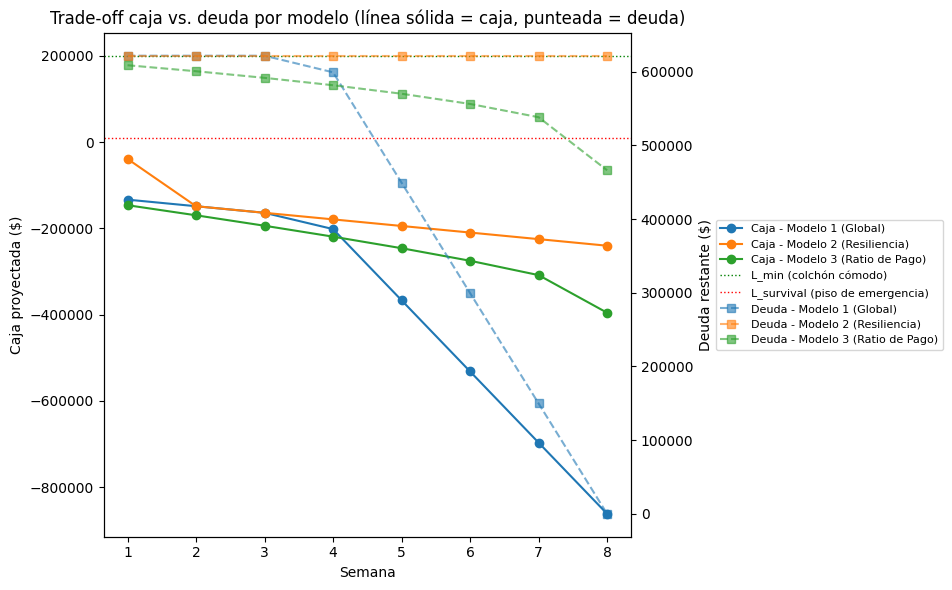

In [14]:
def caja_proyectada(P, I, E, C0):
    IE = np.array(I, dtype=float) - np.array(E, dtype=float)
    pagos_sem = P.sum(axis=0)
    return C0 + np.cumsum(IE) - np.cumsum(pagos_sem)

def deuda_restante_proyectada(P, D0_total):
    pagos_sem = P.sum(axis=0)
    return D0_total - np.cumsum(pagos_sem)

D0_total = sum(D0)

caja_m2 = caja_proyectada(P_2, I, E, C0)
caja_m3 = np.array(res_m3["C_opt"][1:]) if res_m3["exito"] else np.full(T, np.nan)
caja_m5 = caja_proyectada(P_cfo, I, E, C0)

deuda_m2 = deuda_restante_proyectada(P_2, D0_total)
deuda_m3 = np.full(T, D0_total)   # Modelo 2 nunca paga deuda: se queda plana en el total
deuda_m5 = deuda_restante_proyectada(P_cfo, D0_total)

comparacion = pd.DataFrame({
    "Semana": list(range(1, T + 1)),
    "Caja Modelo 1 (Global)": caja_m2,
    "Caja Modelo 2 (Resiliencia)": caja_m3,
    "Caja Modelo 3 (Ratio de Pago)": caja_m5,
    "Deuda restante Modelo 1 (Global)": deuda_m2,
    "Deuda restante Modelo 2 (Resiliencia)": deuda_m3,
    "Deuda restante Modelo 3 (Ratio de Pago)": deuda_m5,
})
print("=== Comparación de caja y deuda restante por modelo ===")
display(comparacion)

resumen = pd.DataFrame({
    "Modelo": ["Modelo 1 (Global)", "Modelo 2 (Resiliencia)", "Modelo 3 (Ratio de Pago)"],
    "Piso de caja mínimo": [caja_m2.min(), res_m3["m_opt"] if res_m3["exito"] else np.nan, caja_m5.min()],
    "Deuda final restante": [deuda_m2[-1], deuda_m3[-1], deuda_m5[-1]],
    "% de deuda pagada": [
        100 * (1 - deuda_m2[-1] / D0_total),
        100 * (1 - deuda_m3[-1] / D0_total),
        100 * (1 - deuda_m5[-1] / D0_total),
    ],
})
print("\n=== Resumen comparativo ===")
display(resumen)

# --- Gráfica de doble eje: Caja (izquierda) vs. Deuda restante (derecha) ---
fig, ax_caja = plt.subplots(figsize=(10, 6))
ax_deuda = ax_caja.twinx()

semanas = comparacion["Semana"]
colores = {"Modelo 1 (Global)": "tab:blue", "Modelo 2 (Resiliencia)": "tab:orange", "Modelo 3 (Ratio de Pago)": "tab:green"}

for modelo, color in colores.items():
    ax_caja.plot(semanas, comparacion[f"Caja {modelo}"], marker="o", color=color,
                 linestyle="-", label=f"Caja - {modelo}")
    ax_deuda.plot(semanas, comparacion[f"Deuda restante {modelo}"], marker="s", color=color,
                  linestyle="--", alpha=0.6, label=f"Deuda - {modelo}")

ax_caja.axhline(L_MIN, color="green", linestyle=":", linewidth=1, label="L_min (colchón cómodo)")
ax_caja.axhline(L_SURVIVAL, color="red", linestyle=":", linewidth=1, label="L_survival (piso de emergencia)")

ax_caja.set_xlabel("Semana")
ax_caja.set_ylabel("Caja proyectada ($)")
ax_deuda.set_ylabel("Deuda restante ($)")
ax_caja.set_title("Trade-off caja vs. deuda por modelo (línea sólida = caja, punteada = deuda)")

lineas1, etiquetas1 = ax_caja.get_legend_handles_labels()
lineas2, etiquetas2 = ax_deuda.get_legend_handles_labels()
ax_caja.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="center left", bbox_to_anchor=(1.15, 0.5), fontsize=8)

plt.tight_layout()
plt.show()